# Reproduced XGBoost SHAP analysis

This notebook retrains an XGBoost classifier from the repository's reduced 18-feature dataset and explains its held-out predictions with SHAP. It does **not** recover the original Databricks/MLflow model, so the resulting ranking must be described as a reproduced analysis rather than the original feature-selection output.

## 1. Install dependencies (Codespaces)
Run this cell once if an import fails, then restart the kernel.

In [6]:
%pip install -q pandas numpy scikit-learn xgboost shap matplotlib pyarrow

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
import json
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import sklearn
import xgboost
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = 'y_mmse_binary'
TEST_SIZE = 0.30
OUTPUT_DIR = Path('results/shap')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    'python': platform.python_version(),
    'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__,
    'xgboost': xgboost.__version__,
    'shap': shap.__version__,
    'matplotlib': matplotlib.__version__,
})

{'python': '3.14.2', 'pandas': '3.0.5', 'scikit-learn': '1.9.1', 'xgboost': '3.4.1', 'shap': '0.52.0', 'matplotlib': '3.11.2'}


## 2. Load and validate the repository data

In [2]:
candidate_paths = [
    Path('testHere/data/alzheimers_balanced_small.csv'),
    Path('../testHere/data/alzheimers_balanced_small.csv'),
    Path('../../testHere/data/alzheimers_balanced_small.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Could not find alzheimers_balanced_small.csv. Run the notebook from the repository root '
        'or place it under testHere/data/.'
    )

df = pd.read_csv(data_path)
if TARGET not in df.columns:
    raise ValueError(f'Missing target column: {TARGET}')
if df[TARGET].isna().any():
    raise ValueError('The target contains missing values.')
if df[TARGET].nunique() != 2:
    raise ValueError('The target must contain exactly two classes.')

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()
non_numeric = X.select_dtypes(exclude=np.number).columns.tolist()
if non_numeric:
    raise TypeError(f'Non-numeric predictor columns require preprocessing: {non_numeric}')

print(f'Data: {data_path.resolve()}')
print(f'Rows: {len(df):,}; predictors: {X.shape[1]}')
display(y.value_counts().sort_index().rename('count').to_frame())
display(X.isna().sum().sort_values(ascending=False).rename('missing').to_frame().head(10))

Data: /workspaces/ADNI/testHere/data/alzheimers_balanced_small.csv
Rows: 864; predictors: 18


,count
y_mmse_binary,
0,432
1,432


,missing
NPIG,530
MMO,314
MMR,314
MMW,314
VSHEIGHT,194
VSTMPSRC,133
VSTEMP,126
VSBPSYS,117
VSPULSE,117
VSWEIGHT,111


## 3. Create an untouched test set and tune using training data only
The split is stratified and reproducible. Cross-validation and hyperparameter selection use only the training partition; the test partition is reserved for final metrics and SHAP explanations.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method='hist',
)

parameter_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(
    estimator=base_model,
    param_grid=parameter_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)
search.fit(X_train, y_train)
model = search.best_estimator_

print('Best cross-validated training ROC-AUC:', round(search.best_score_, 6))
print('Best parameters:', search.best_params_)

Best cross-validated training ROC-AUC: 0.956385
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [4]:
test_probability = model.predict_proba(X_test)[:, 1]
test_prediction = model.predict(X_test)
test_metrics = {
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'accuracy': float(accuracy_score(y_test, test_prediction)),
    'roc_auc': float(roc_auc_score(y_test, test_probability)),
}
print(json.dumps(test_metrics, indent=2))
print(classification_report(y_test, test_prediction, digits=4))

pd.DataFrame([test_metrics]).to_csv(OUTPUT_DIR / 'xgboost_test_metrics.csv', index=False)
with open(OUTPUT_DIR / 'xgboost_best_parameters.json', 'w', encoding='utf-8') as file:
    json.dump(search.best_params_, file, indent=2)

{
  "n_train": 604,
  "n_test": 260,
  "accuracy": 0.8923076923076924,
  "roc_auc": 0.9350295857988166
}
              precision    recall  f1-score   support

           0     0.8750    0.9154    0.8947       130
           1     0.9113    0.8692    0.8898       130

    accuracy                         0.8923       260
   macro avg     0.8931    0.8923    0.8923       260
weighted avg     0.8931    0.8923    0.8923       260



## 4. Compute held-out SHAP values
SHAP values are calculated for the untouched test observations. Global importance is the mean absolute SHAP value across these observations.

In [5]:
explainer = shap.TreeExplainer(model)
raw_shap_values = explainer.shap_values(X_test)

# Normalize common SHAP return formats to (observations, features).
if isinstance(raw_shap_values, list):
    shap_values = np.asarray(raw_shap_values[-1])
else:
    shap_values = np.asarray(raw_shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]
if shap_values.shape != X_test.shape:
    raise ValueError(
        f'Unexpected SHAP shape {shap_values.shape}; expected {X_test.shape}.'
    )

importance = (
    pd.DataFrame({
        'feature': X_test.columns,
        'mean_absolute_shap': np.abs(shap_values).mean(axis=0),
        'mean_signed_shap': shap_values.mean(axis=0),
    })
    .sort_values('mean_absolute_shap', ascending=False)
    .reset_index(drop=True)
)
importance.insert(0, 'rank', np.arange(1, len(importance) + 1))
importance.to_csv(OUTPUT_DIR / 'xgboost_shap_importance.csv', index=False)
display(importance)

,rank,feature,mean_absolute_shap,mean_signed_shap
0,1,WORD1DL,1.251245,-0.117838
1,2,WORD2DL,0.769498,-0.138290
2,3,WORD3DL,0.753440,-0.147582
3,4,MMDRAW,0.558782,0.019509
4,5,MMREPEAT,0.344737,0.000945
5,6,MMW,0.315120,0.005547
6,7,MMO,0.302954,-0.014498
7,8,MMHAND,0.230817,0.008610
8,9,VSTEMP,0.211021,0.022485
9,10,NPIG,0.201818,0.013966


## 5. Manuscript Figure A: global SHAP importance
Longer bars indicate a larger average influence on the model output. The plot ranks influence magnitude; it does not indicate whether high values increase or decrease predictions.

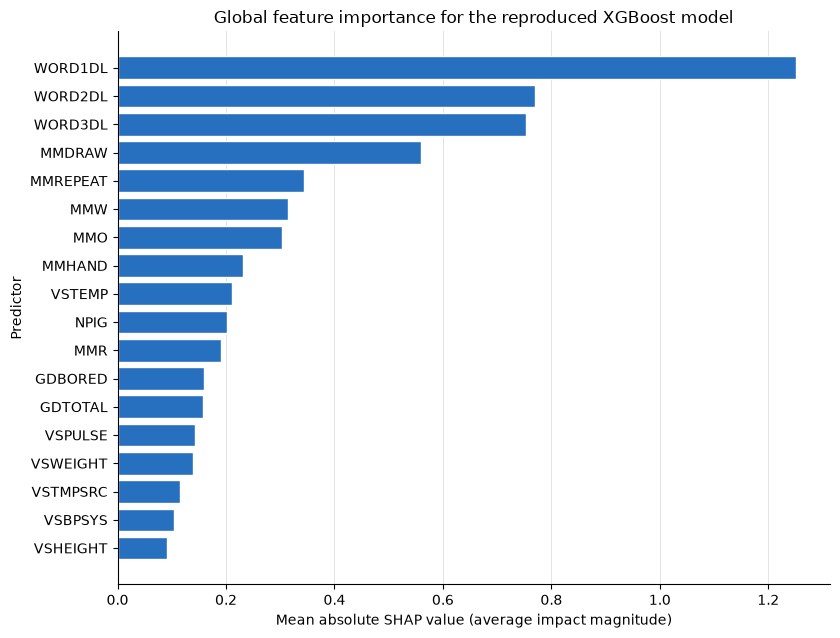

In [6]:
plot_data = importance.sort_values('mean_absolute_shap', ascending=True)
fig_height = max(5.5, 0.36 * len(plot_data))
fig, ax = plt.subplots(figsize=(8.5, fig_height))
ax.barh(
    plot_data['feature'],
    plot_data['mean_absolute_shap'],
    color='#276FBF',
    edgecolor='white',
)
ax.set_xlabel('Mean absolute SHAP value (average impact magnitude)')
ax.set_ylabel('Predictor')
ax.set_title('Global feature importance for the reproduced XGBoost model')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#D9D9D9', linewidth=0.7, alpha=0.75)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_shap_global_importance.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_shap_global_importance.pdf', bbox_inches='tight')
plt.show()

## 6. Manuscript Figure B: SHAP beeswarm
Each point represents one held-out observation. Horizontal position is that feature's contribution to the model output; color represents the observed feature value. This figure provides direction and variability, which the bar chart cannot show.

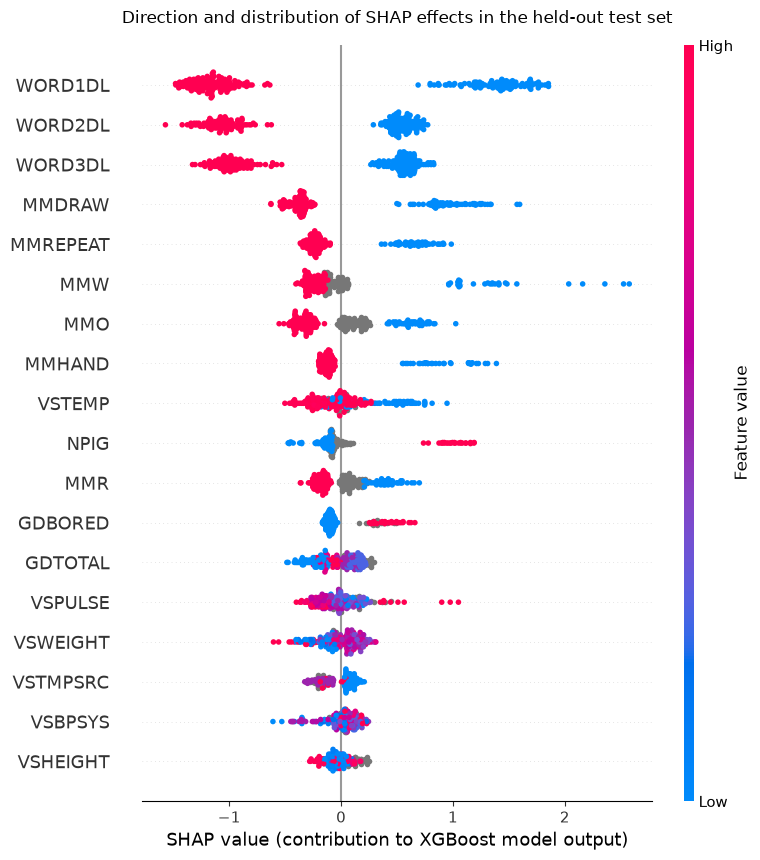

In [7]:
plt.figure(figsize=(9.5, max(6.0, 0.38 * X_test.shape[1])))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    max_display=X_test.shape[1],
    show=False,
)
plt.title('Direction and distribution of SHAP effects in the held-out test set', pad=16)
plt.xlabel('SHAP value (contribution to XGBoost model output)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'figure_shap_beeswarm.pdf', bbox_inches='tight')
plt.show()

## 7. Suggested manuscript wording

**Methods:** `SHAP values were computed for the tuned XGBoost classifier using TreeExplainer and the held-out test partition. Global feature importance was summarized as the mean absolute SHAP value across test observations. A beeswarm plot was used to visualize the magnitude, direction, and distribution of feature contributions.`

**Figure A caption:** `Global SHAP importance for the reproduced XGBoost model. Predictors are ranked by mean absolute SHAP value across held-out test observations; larger values denote greater average influence on the model output. Importance reflects model behavior and does not establish causality.`

**Figure B caption:** `SHAP beeswarm plot for the reproduced XGBoost model in the held-out test set. Each point represents one observation. Positive and negative SHAP values indicate contributions toward higher and lower model output, respectively, while color represents the observed feature value.`

